<a href="https://colab.research.google.com/github/SubhanaJamil/10x_Genomics_Spatial_Methods/blob/main/Analyze_Xenium_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
get_ipython().system('pip install spatialdata spatialdata-io squidpy')
import spatialdata as sd
from spatialdata_io import xenium

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

In [2]:
xenium_path = "./Xenium"
zarr_path = "./Xenium.zarr"

In [16]:
!mkdir -p Xenium
!wget -O Xenium/data.zip "https://cf.10xgenomics.com/samples/xenium/4.0.0/Xenium_V1_Protein_Human_Kidney_tiny/Xenium_V1_Protein_Human_Kidney_tiny_outs.zip"
!unzip Xenium/data.zip -d Xenium/
from spatialdata_io import xenium

sdata = xenium("./Xenium", cells_as_circles=True)
print(sdata)

--2026-05-01 18:09:27--  https://cf.10xgenomics.com/samples/xenium/4.0.0/Xenium_V1_Protein_Human_Kidney_tiny/Xenium_V1_Protein_Human_Kidney_tiny_outs.zip
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.0.173, 104.18.1.173, 2606:4700::6812:ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.0.173|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20929485 (20M) [application/zip]
Saving to: ‘Xenium/data.zip’

Xenium/data.zip     100%[===================>]  19.96M  12.5MB/s    in 1.6s    

2026-05-01 18:09:29 (12.5 MB/s) - ‘Xenium/data.zip’ saved [20929485/20929485]

Archive:  Xenium/data.zip
  inflating: Xenium/protein_panel.json  
   creating: Xenium/morphology_focus/
  inflating: Xenium/morphology_focus/ch0003_alphasma_vimentin.ome.tif  
  inflating: Xenium/morphology_focus/ch0011_lag-3.ome.tif  
  inflating: Xenium/morphology_focus/ch0007_red_background.ome.tif  
  inflating: Xenium/morphology_focus/ch0004_blue_background.ome.tif  
 

/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              
SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (12, 6915, 2963), (12, 3457, 1481), (12, 1728, 740), (12, 864, 370), (12, 432, 185)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (6915, 2963), (3457, 1481), (1728, 740), (864, 370), (432, 185)
│     └── 'nucleus_labels': DataTree[yx] (6915, 2963), (3457, 1481), (1728, 740), (864, 370), (432, 185)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (358, 1) (2D s

In [19]:
import zarr
zarr.config.set({'array.rectilinear_chunks': True})
sdata.write("./Xenium.zarr", overwrite=True)

/usr/local/lib/python3.12/dist-packages/pims/tiff_stack.py:131: UserWarning: <tifffile.TiffPage 0 @16> reading array from closed file
  data = t.asarray()


In [24]:
from spatialdata_io import xenium

sdata = xenium("./Xenium", cells_as_circles=True)
sdata.write("Xenium.zarr", overwrite=True)   # recreate zarr properly

/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              


/usr/local/lib/python3.12/dist-packages/pims/tiff_stack.py:131: UserWarning: <tifffile.TiffPage 0 @16> reading array from closed file
  data = t.asarray()


In [49]:
adata = sdata.tables["table"]

# Initialize adata.uns['spatial'] for squidpy plotting
if "spatial" not in adata.uns:
    adata.uns["spatial"] = {}
adata.uns["spatial"]["spatial"] = {
    "images": {},
    "scalefactors": {},
    "metadata": {
        "obsm_key": "spatial"
    },
}
adata

AnnData object with n_obs × n_vars = 334 × 254
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'spatialdata_attrs', 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'spatial_neighbors', 'leiden_centrality_scores', 'leiden_nhood_enrichment', 'spatial'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp

In [26]:
adata.obs

,cell_id,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,nucleus_count,segmentation_method,region,z_level,cell_labels
0,aadmbfof-1,29,0,0,0,0,0,29,43.891877,18.423751,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_circles,0.0,1
1,aageapbo-1,46,0,0,0,0,0,46,42.221095,23.120001,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_circles,0.0,2
2,aakefffb-1,27,0,0,0,0,0,27,18.243126,12.734063,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_circles,0.0,3
3,abkjennb-1,29,0,0,0,0,0,29,41.047033,28.493595,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_circles,0.0,4
4,acdcmlfl-1,40,0,0,0,0,0,40,22.081407,13.637188,1.0,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,cell_circles,0.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353,ofijgekj-1,24,0,0,0,0,0,24,36.666876,12.508282,1.0,Segmented by nucleus expansion of 5.0µm,cell_circles,3.0,354
354,ofikancd-1,57,0,0,0,0,0,57,78.346097,23.436095,1.0,Segmented by nucleus expansion of 5.0µm,cell_circles,3.0,355
355,oflomkib-1,22,0,0,0,0,0,22,45.020783,8.444219,1.0,Segmented by nucleus expansion of 5.0µm,cell_circles,4.0,356
356,ogneoico-1,88,0,0,0,0,0,88,137.320161,15.443438,1.0,Segmented by nucleus expansion of 5.0µm,cell_circles,4.0,357


In [27]:
adata.obsm["spatial"]

array([[ 64.64482117, 613.75860596],
       [107.50011444, 621.21313477],
       [123.23633575, 630.40545654],
       [116.32388306, 627.98864746],
       [122.88692474, 626.17773438],
       [119.04171753, 622.41473389],
       [105.66311646, 617.04644775],
       [ 97.0734024 , 626.52178955],
       [103.02433014, 628.43084717],
       [100.68579102, 614.05413818],
       [106.91308594, 743.52886963],
       [101.52613068, 776.80273438],
       [ 98.93094635, 772.27966309],
       [108.34395599, 771.6618042 ],
       [113.08798981, 778.80950928],
       [120.51985168, 775.2845459 ],
       [115.17956543, 768.80072021],
       [120.73622894, 765.0380249 ],
       [ 80.45597839, 626.62225342],
       [ 86.23369598, 786.3137207 ],
       [ 87.7855835 , 760.84161377],
       [ 90.2285614 , 629.17907715],
       [ 87.97286987, 622.96643066],
       [ 61.28203583, 771.52056885],
       [ 44.50024796, 785.83502197],
       [ 47.19268799, 778.87683105],
       [ 58.64902878, 763.24749756],
 

In [28]:
sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

In [29]:
cprobes = (
    adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
cwords = (
    adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
print(f"Negative DNA probe count % : {cprobes}")
print(f"Negative decoding count % : {cwords}")

Negative DNA probe count % : 0.01163534818779452
Negative decoding count % : 0.00581767409389726


<Axes: title={'center': 'Nucleus ratio'}, ylabel='Count'>

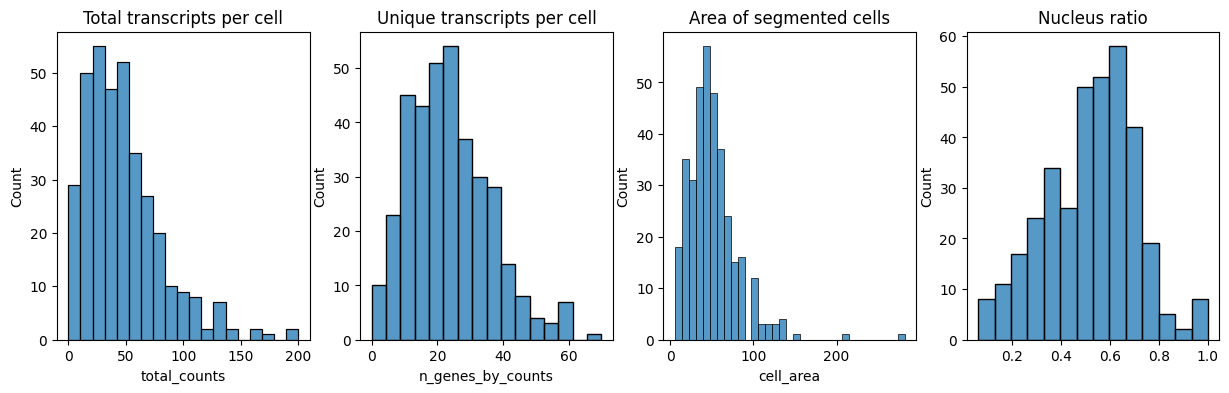

In [30]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))

axs[0].set_title("Total transcripts per cell")
sns.histplot(
    adata.obs["total_counts"],
    kde=False,
    ax=axs[0],
)

axs[1].set_title("Unique transcripts per cell")
sns.histplot(
    adata.obs["n_genes_by_counts"],
    kde=False,
    ax=axs[1],
)


axs[2].set_title("Area of segmented cells")
sns.histplot(
    adata.obs["cell_area"],
    kde=False,
    ax=axs[2],
)

axs[3].set_title("Nucleus ratio")
sns.histplot(
    adata.obs["nucleus_area"] / adata.obs["cell_area"],
    kde=False,
    ax=axs[3],
)

In [31]:
sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)

In [33]:
!pip install leidenalg
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 117.4 MB/s eta 0:00:00


/tmp/ipykernel_5434/4093588716.py:8: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


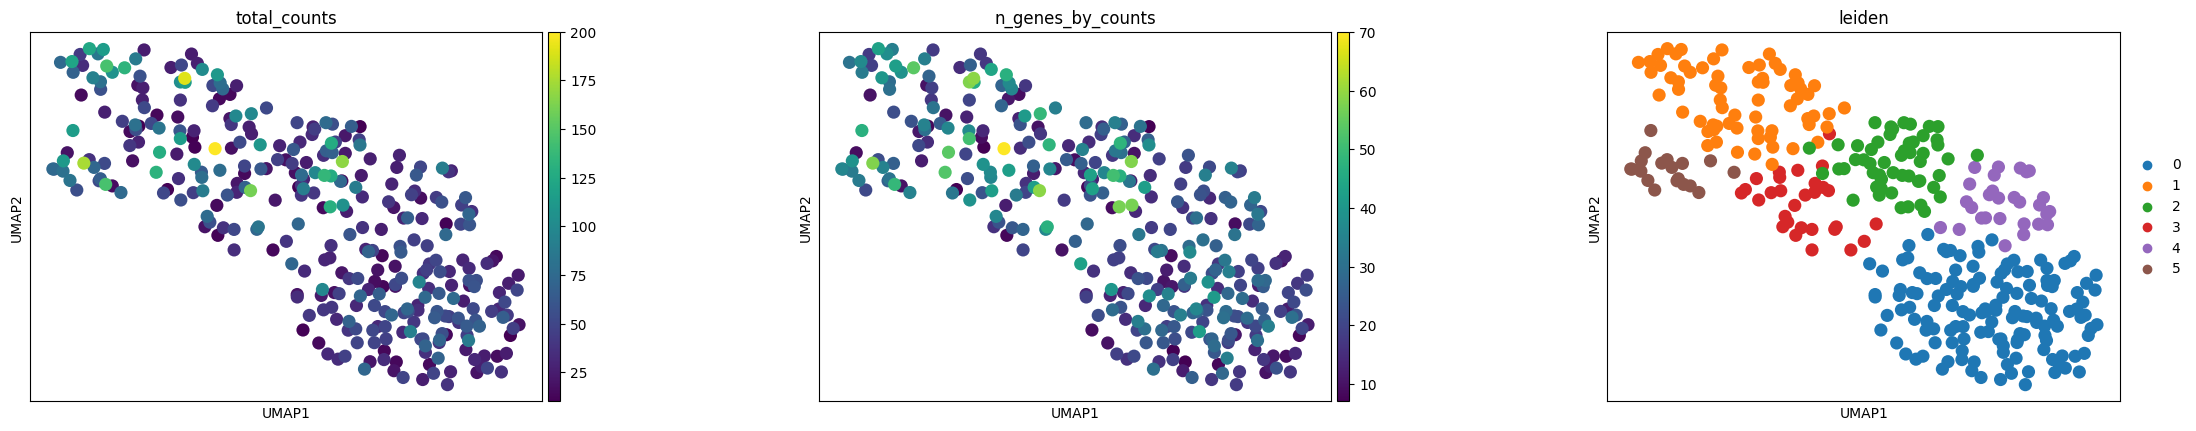

In [34]:
sc.pl.umap(
    adata,
    color=[
        "total_counts",
        "n_genes_by_counts",
        "leiden",
    ],
    wspace=0.4,
)

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


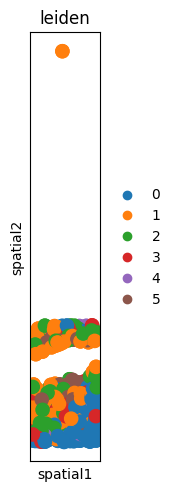

In [35]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "leiden",
    ],
    wspace=0.4,
)

In [36]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


In [37]:
sq.gr.centrality_scores(adata, cluster_key="leiden")

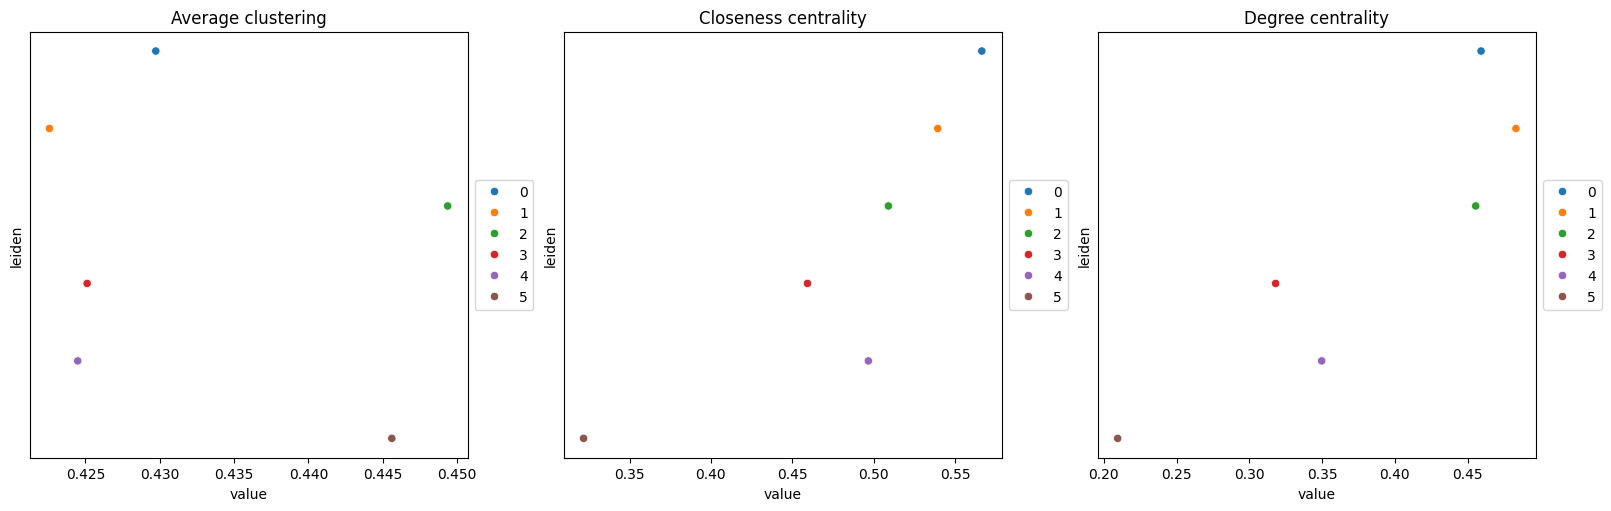

In [38]:
sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(16, 5))

In [39]:
sdata.tables["subsample"] = sc.pp.subsample(adata, fraction=0.5, copy=True)

In [40]:
adata_subsample = sdata.tables["subsample"]

In [48]:
if 'spatial' not in adata_subsample.uns or adata_subsample.uns['spatial'] is None:
    adata_subsample.uns['spatial'] = adata.uns['spatial'].copy()

sq.gr.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
)
sq.pl.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
    clusters=["1", "2"],
    figsize=(10, 10),
)
sq.pl.spatial_scatter(
    adata_subsample,
    color="leiden",
    shape=None,
    size=2,
    library_id="spatial"
)

KeyError: 'spatial'

In [43]:
sq.gr.nhood_enrichment(adata, cluster_key="leiden")

  0%|          | 0/1000 [00:00<?, ?/s]

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


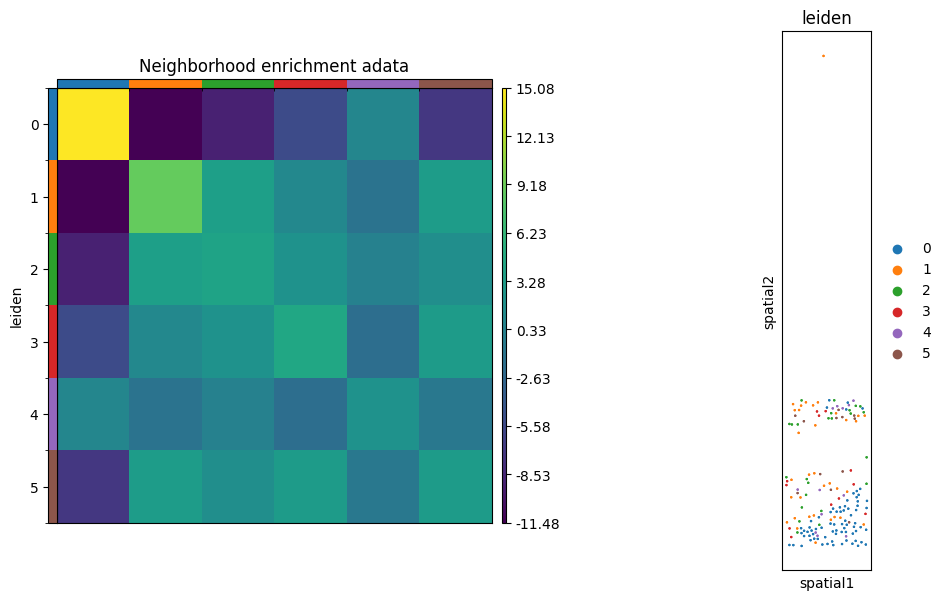

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden",
    figsize=(8, 8),
    title="Neighborhood enrichment adata",
    ax=ax[0],
)
sq.pl.spatial_scatter(adata_subsample, color="leiden", shape=None, size=2, ax=ax[1])

In [46]:
sq.gr.spatial_neighbors(adata_subsample, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata_subsample,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)
adata_subsample.uns["moranI"].head(10)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


  0%|          | 0/100 [00:00<?, ?/s]

,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
MS4A1,0.599362,0.000000e+00,0.002025,0.000000e+00,0.009901,0.002896,0.000000e+00,0.000000e+00,0.062871
TFPI,0.344192,3.552714e-15,0.002025,2.137179e-13,0.009901,0.002219,4.511946e-13,1.809478e-11,0.062871
HLA-DRA,0.309262,1.225131e-12,0.002025,1.305694e-09,0.009901,0.002790,1.037278e-10,5.614361e-08,0.062871
THBS2,0.290303,2.277356e-11,0.002025,1.472156e-13,0.009901,0.001609,1.446121e-09,1.809478e-11,0.062871
CXCR4,0.281952,7.806733e-11,0.002025,3.589037e-08,0.009901,0.002657,3.965820e-09,9.116153e-07,0.062871
CD79A,0.250944,5.641695e-09,0.002025,1.308105e-09,0.009901,0.001770,2.388317e-07,5.614361e-08,0.062871
DUSP2,0.237265,3.218056e-08,0.002025,1.574608e-05,0.019802,0.003156,1.167695e-06,2.352650e-04,0.089816
BANK1,0.233259,5.268558e-08,0.002025,4.214531e-09,0.009901,0.001718,1.672767e-06,1.529273e-07,0.062871
EGFL7,0.227709,1.029776e-07,0.002025,2.183759e-07,0.009901,0.001931,2.906258e-06,4.266729e-06,0.062871
ACKR1,0.223113,1.773743e-07,0.002025,9.657734e-09,0.009901,0.001618,4.505307e-06,3.066330e-07,0.062871


['ACKR1', 'ACTA2']


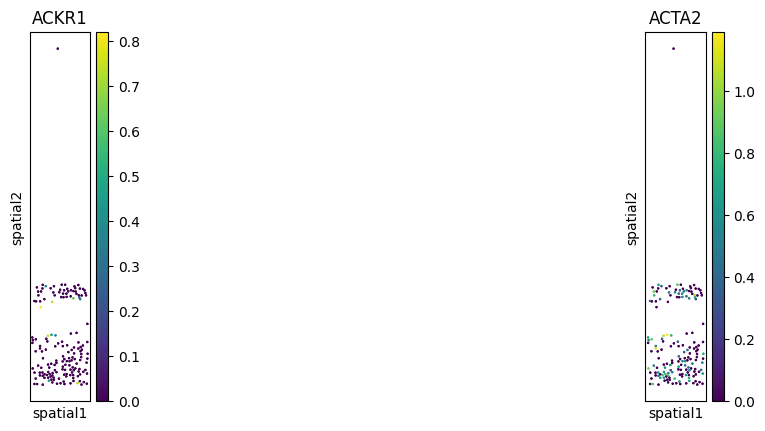

In [51]:
genes = list(adata.var_names[:2])
print(genes)
sq.pl.spatial_scatter(
    adata_subsample,
    library_id="spatial",
    color=genes,
    shape=None,
    size=2,
    img=False,
)

/usr/local/lib/python3.12/dist-packages/pims/tiff_stack.py:131: UserWarning: <tifffile.TiffPage 0 @16> reading array from closed file
  data = t.asarray()
/usr/local/lib/python3.12/dist-packages/pims/tiff_stack.py:131: UserWarning: <tifffile.TiffPage 0 @16> reading array from closed file
  data = t.asarray()


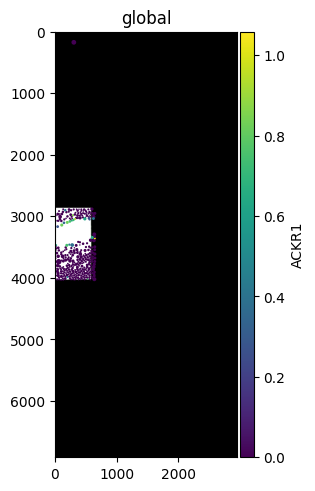

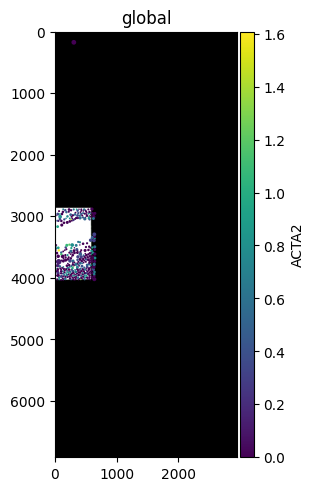

In [58]:
sdata.pl.render_images("morphology_focus").pl.render_shapes(
    "cell_circles",
    table_name="table",
    use_raw=False,
    color="ACKR1"
).pl.show()
sdata.pl.render_images("morphology_focus").pl.render_shapes(
    "cell_circles",
    table_name="table",
    use_raw=False,
    color="ACTA2"
).pl.show()

In [ ]:
!pip install napari-spatialdata PyQt5
!Xvfb :99 -ac & display=:99

from napari_spatialdata import Interactive

Interactive(sdata)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.4/282.4 kB 19.0 MB/s eta 0:00:00
